# FEMT-Net — Kaggle Implementation

## Federated Explainable Multimodal Transformer Network for Cardiovascular Disease Prediction

> **Environment:** Kaggle GPU notebook · PyTorch + CrossEntropyLoss (2-class) · batch_size=32 · epochs=10

**Datasets (add via Kaggle "Add Data"):**
- ECG waveforms: [`m0hamedyousry/ptb-xl-a-large-publicly-available-ecg-dataset`](https://www.kaggle.com/datasets/m0hamedyousry/ptb-xl-a-large-publicly-available-ecg-dataset)
- Clinical tabular: [`redwankarimsony/heart-disease-data`](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

Pipeline:
1. **Raw 12-lead ECG waveforms** (PTB-XL, 500 Hz / 100 Hz, 12 leads)
2. **Structured clinical features** (UCI Heart Disease — `heart_disease_uci.csv`, label = `num`)
3. CNN ECG encoder → MLP clinical encoder → Modality Gate → Transformer → 2-class Classifier
4. Centralized training baseline → Federated learning (weighted FedAvg, 3 clients, 5 rounds)
5. Explainability: SHAP (clinical surrogate), modality attention, Grad-CAM ECG saliency

---

## 📋 FEMT-Net Architecture Overview

```
ECG Waveforms (12-lead, 5000 ts)     Clinical Features (UCI / PTB-XL metadata)
              │                                     │
              ▼                                     ▼
   ECG Encoder (1D CNN, 128-d)      Clinical Encoder (MLP, 32-d)
              │                                     │
              └────────── Modality Gate ────────────┘
                             │
                             ▼
                  Transformer Encoder (2 layers, 4 heads)
                             │
                             ▼
                  Classification Head → 2 classes (Normal / Disease)
                             │
                             ▼
           Centralized / Federated Training (CrossEntropyLoss)
                             │
                             ▼
     Explainability (SHAP + Modality Attention + Grad-CAM ECG Saliency)
```

## 🔧 STEP 1: Install Extra Dependencies

Kaggle already ships PyTorch with GPU support. We only need `wfdb` (ECG waveform reader) and `shap` (explainability).

In [12]:
# Kaggle already ships PyTorch + torchvision + torchaudio with GPU support.
# Only install the extra packages needed for ECG loading and explainability.
!pip install -q wfdb shap

print("✅ FEMT-Net dependencies installed")

✅ FEMT-Net dependencies installed


'pip' is not recognized as an internal or external command,
operable program or batch file.


## 📦 STEP 2: Import Libraries and Configure GPU

Sets deterministic seeds, enables cuDNN benchmark mode, and selects CUDA if available.

In [13]:
import ast
import copy
import os
import pickle
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, Subset

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using device: {device}")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

🔥 Using device: cuda


## 📊 STEP 3 (KAGGLE): Load Multimodal Datasets

> ⚠️ **Kaggle-only cell.** Set `RUNNING_ON_KAGGLE = False` (default) to skip this cell when running locally on your PC/laptop. Use **STEP 3 (LOCAL)** below instead.

Add both datasets to your Kaggle notebook via **Add Data**:

| Source | Kaggle Slug | Kaggle Input Path | Key File |
|--------|------------|-------------------|----------|
| **UCI Heart Disease** | `redwankarimsony/heart-disease-data` | `/kaggle/input/heart-disease-data/` | `heart_disease_uci.csv` (label col = `num`) |
| **PTB-XL ECG** | `m0hamedyousry/ptb-xl-a-large-publicly-available-ecg-dataset` | `/kaggle/input/ptb-xl-a-large-publicly-available-ecg-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/` | `ptbxl_database.csv`, `scp_statements.csv`, `records100/`, `records500/` |

UCI rows are **cyclically mapped** to ECG samples: `uci[i % len(uci_df)]`


In [14]:
# ── Constants ──────────────────────────────────────────────────────────────
ECG_FIXED_LEN = 5000          # 500 Hz × 10 s
MAX_ECG_RECORDS = 21837       # load full PTB-XL dataset (all 21837 records)

# UCI clinical feature columns (13 features, excluding the label)
UCI_FEATURE_COLS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# ── Shared helper functions (always defined — used by both Kaggle & Local) ─
def aggregate_ptbxl_targets(df_raw, dataset_root):
    import pandas as _pd
    scp_df = _pd.read_csv(dataset_root / 'scp_statements.csv', index_col=0)
    scp_df = scp_df[scp_df['diagnostic'] == 1]

    def aggregate_diagnostic(scp_codes):
        classes = []
        for code in scp_codes.keys():
            if code in scp_df.index:
                classes.append(scp_df.loc[code, 'diagnostic_class'])
        return sorted(list(set(classes)))

    df_raw['diagnostic_superclass'] = df_raw['scp_codes'].apply(aggregate_diagnostic)
    df_raw['target'] = df_raw['diagnostic_superclass'].apply(
        lambda classes: 0 if 'NORM' in classes else 1 if len(classes) > 0 else -1
    )
    return df_raw[df_raw['target'] != -1].copy()

def normalize_ecg(signal):
    signal = signal.astype(np.float32)
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True) + 1e-6
    return (signal - mean) / std

def build_synthetic_multimodal_dataset(num_samples=400, num_leads=12, signal_length=1000):
    _feat_names = ['age', 'sex', 'cholesterol', 'resting_bp',
                   'max_heart_rate', 'st_depression', 'bmi', 'smoking']
    _labels = np.random.binomial(1, 0.5, size=num_samples).astype(np.int64)
    _ecg = np.random.normal(0, 0.15, size=(num_samples, num_leads, signal_length)).astype(np.float32)
    _region = slice(signal_length // 3, signal_length // 3 + 60)
    _ecg[_labels == 1, :, _region] += 0.9
    _ecg[_labels == 1, :, _region.start + 80:_region.start + 120] -= 0.4
    _clin = pd.DataFrame({
        'age':            np.random.normal(55 + 8 * _labels,  8,   size=num_samples),
        'sex':            np.random.binomial(1, 0.55,              size=num_samples),
        'cholesterol':    np.random.normal(190 + 40 * _labels, 25, size=num_samples),
        'resting_bp':     np.random.normal(120 + 18 * _labels, 10, size=num_samples),
        'max_heart_rate': np.random.normal(155 - 15 * _labels, 12, size=num_samples),
        'st_depression':  np.random.normal(0.8 + 1.0 * _labels, 0.4, size=num_samples),
        'bmi':            np.random.normal(25 + 4 * _labels,  2.5, size=num_samples),
        'smoking':        np.random.binomial(1, 0.25 + 0.25 * _labels, size=num_samples),
    }).astype(np.float32)
    print("⚠️ PTB-XL waveforms not found. Falling back to synthetic multimodal data.")
    return {
        'dataset_name': 'Synthetic-Multimodal',
        'ecg_array': _ecg,
        'fallback_clinical_df': _clin,
        'fallback_clinical_cols': _feat_names,
        'labels': _labels,
        'signal_length': signal_length,
        'num_leads': num_leads,
        'record_ids': list(range(num_samples)),
    }

# ══════════════════════════════════════════════════════════════════════════
#  KAGGLE ENVIRONMENT GUARD
#  ▶ Set RUNNING_ON_KAGGLE = True  when running on Kaggle.
#  ▶ Set RUNNING_ON_KAGGLE = False (default) to skip and use LOCAL cell below.
# ══════════════════════════════════════════════════════════════════════════
RUNNING_ON_KAGGLE = False   # ← flip to True on Kaggle

if not RUNNING_ON_KAGGLE:
    print("⏩  Kaggle data-loading skipped (RUNNING_ON_KAGGLE=False).")
    print("    ▶ Run the LOCAL LAPTOP cell below to load data from your PC.")
else:
    # ── UCI Heart Disease (Kaggle paths) ──────────────────────────────────
    UCI_CANDIDATES = [
        Path('/kaggle/input/heart-disease-data/heart_disease_uci.csv'),
        Path('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv'),
        Path('/kaggle/input/uci-heart-disease/heart.csv'),
        Path('/kaggle/input/heart-disease-uci/heart.csv'),
        Path('heart_disease_uci.csv'),
    ]

    uci_df = None
    for p in UCI_CANDIDATES:
        if p.exists():
            uci_df = pd.read_csv(p)
            print(f"✅ UCI Heart Disease loaded from {p}  ({len(uci_df)} rows)")
            break

    if uci_df is None:
        for csv_path in Path('/kaggle/input').rglob('heart_disease_uci.csv') if Path('/kaggle/input').exists() else []:
            uci_df = pd.read_csv(csv_path)
            print(f"✅ UCI Heart Disease found via search at {csv_path}  ({len(uci_df)} rows)")
            break

    if uci_df is not None:
        if 'num' in uci_df.columns:
            uci_label_col = 'num'
        elif 'target' in uci_df.columns:
            uci_label_col = 'target'
        else:
            raise KeyError("UCI CSV has no 'num' or 'target' column")
        uci_df[uci_label_col] = (uci_df[uci_label_col] > 0).astype(int)
        print(f"   Label column : {uci_label_col} (reference only – ECG labels drive training)")
        print(uci_df[uci_label_col].value_counts())
    else:
        print("⚠️  UCI Heart Disease CSV not found – will use PTB-XL metadata as clinical features.")

    # ── PTB-XL ECG Waveforms (Kaggle paths) ──────────────────────────────
    def find_ptbxl_root():
        search_roots = [
            Path('/kaggle/input/ptb-xl-a-large-publicly-available-ecg-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'),
            Path('/kaggle/input/ptb-xl-a-large-publicly-available-ecg-dataset'),
            Path('/kaggle/input/datasets/m0hamedyousry/ptb-xl-a-large-publicly-available-ecg-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'),
            Path('/kaggle/input/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'),
            Path('/kaggle/input/ptb-xl-dataset'),
            Path('/kaggle/input/ptb-xl'),
            Path.cwd() / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
        ]
        for candidate in search_roots:
            if (candidate / 'ptbxl_database.csv').exists():
                return candidate
        kaggle_input = Path('/kaggle/input')
        if kaggle_input.exists():
            for csv_path in kaggle_input.rglob('ptbxl_database.csv'):
                return csv_path.parent
        return None

    def load_ptbxl_multimodal_dataset(max_records=MAX_ECG_RECORDS):
        dataset_root = find_ptbxl_root()
        if dataset_root is None:
            return None
        print(f"✅ PTB-XL root found at: {dataset_root}")
        df_raw = pd.read_csv(dataset_root / 'ptbxl_database.csv', index_col='ecg_id')
        df_raw['scp_codes'] = df_raw['scp_codes'].apply(ast.literal_eval)
        df_raw = aggregate_ptbxl_targets(df_raw, dataset_root)

        ptbxl_meta_candidates = ['age','sex','height','weight','heart_axis','infarction_stadium1',
            'infarction_stadium2','validated_by','second_opinion','initial_autogenerated_report',
            'baseline_drift','static_noise','burst_noise','electrodes_problems','extra_beats','pacemaker']
        ptbxl_meta_cols = [col for col in ptbxl_meta_candidates if col in df_raw.columns] or ['age','sex','height','weight']

        normal_df  = df_raw[df_raw['target'] == 0]
        disease_df = df_raw[df_raw['target'] == 1]
        per_class  = max_records // 2
        sampled = pd.concat([
            normal_df.sample( n=min(len(normal_df),  per_class), random_state=42),
            disease_df.sample(n=min(len(disease_df), per_class), random_state=42),
        ]).sample(frac=1.0, random_state=42)

        use_hr = False
        if 'filename_hr' in sampled.columns:
            use_hr = (dataset_root / f"{sampled.iloc[0]['filename_hr']}.hea").exists()
        record_field  = 'filename_hr' if use_hr else 'filename_lr'
        target_length = ECG_FIXED_LEN if use_hr else 1000

        ptbxl_meta_df = sampled[ptbxl_meta_cols].apply(pd.to_numeric, errors='coerce')
        ecg_signals, meta_rows, label_list, loaded_ids = [], [], [], []
        skipped = 0
        for ecg_id, row in sampled.iterrows():
            try:
                signal, _ = wfdb.rdsamp(str(dataset_root / row[record_field]))
                signal = normalize_ecg(signal)
                if signal.shape[0] >= target_length:
                    signal = signal[:target_length]
                else:
                    signal = np.vstack([signal, np.zeros((target_length - signal.shape[0], signal.shape[1]), np.float32)])
                ecg_signals.append(signal.T.astype(np.float32))
                meta_rows.append(ptbxl_meta_df.loc[ecg_id].values.astype(np.float32))
                label_list.append(int(row['target']))
                loaded_ids.append(ecg_id)
            except Exception:
                skipped += 1

        if not ecg_signals:
            return None
        ecg_array = np.stack(ecg_signals)
        labels = np.array(label_list, dtype=np.int64)
        print(f"✅ Loaded {len(labels)} ECG records  |  leads={ecg_array.shape[1]}  |  timesteps={ecg_array.shape[2]}")
        print(f"   Skipped records: {skipped}")
        return {
            'dataset_name': 'PTB-XL',
            'ecg_array': ecg_array,
            'fallback_clinical_df': pd.DataFrame(meta_rows, columns=ptbxl_meta_cols, index=loaded_ids),
            'fallback_clinical_cols': ptbxl_meta_cols,
            'labels': labels,
            'signal_length': int(ecg_array.shape[2]),
            'num_leads': int(ecg_array.shape[1]),
            'record_ids': loaded_ids,
        }

    # ── Load ECG data ─────────────────────────────────────────────────────
    dataset_bundle = load_ptbxl_multimodal_dataset(max_records=MAX_ECG_RECORDS)
    if dataset_bundle is None:
        dataset_bundle = build_synthetic_multimodal_dataset()

    ecg_array     = dataset_bundle['ecg_array']
    labels        = dataset_bundle['labels']
    signal_length = dataset_bundle['signal_length']
    num_leads     = dataset_bundle['num_leads']
    dataset_name  = dataset_bundle['dataset_name']

    # ── UCI cyclic mapping: ecg[i] → uci[i % len(uci_df)] ───────────────
    if uci_df is not None:
        uci_feature_cols = [c for c in UCI_FEATURE_COLS if c in uci_df.columns]
        uci_feat_df = uci_df[uci_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        n_ecg = len(ecg_array)
        idx = np.arange(n_ecg) % len(uci_feat_df)   # clinical_data[i % 303]
        clinical_array = uci_feat_df.values[idx].astype(np.float32)
        clinical_df = pd.DataFrame(clinical_array, columns=uci_feature_cols)
        clinical_feature_names = uci_feature_cols
        print(f"\n✅ UCI clinical features cyclically mapped: {len(uci_feat_df)} rows → {n_ecg} "
              f"(cycle length = {len(uci_feat_df)})")
        print(f"   UCI features: {uci_feature_cols}")
    else:
        clinical_df = dataset_bundle['fallback_clinical_df']
        clinical_feature_names = dataset_bundle['fallback_clinical_cols']
        print("\n⚠️ UCI not available – using PTB-XL metadata as clinical features")

    print(f"\n✅ Dataset ready : {dataset_name}")
    print(f"   ECG shape     : {ecg_array.shape}")
    print(f"   Clinical shape: {clinical_df.shape}")
    print(f"   Labels        : {np.bincount(labels)}  (0=NORM, 1=disease)")
    print(f"   Features      : {clinical_feature_names}")


⏩  Kaggle data-loading skipped (RUNNING_ON_KAGGLE=False).
    ▶ Run the LOCAL LAPTOP cell below to load data from your PC.


## 📊 STEP 3 (LOCAL LAPTOP): Load Multimodal Datasets from Your PC

Use this cell when running **locally on your PC/laptop**. The Kaggle cell above is disabled with `RUNNING_ON_KAGGLE = False`.

| Source | Local Path |
|--------|-----------|
| **PTB-XL ECG** | `ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/` (already in project folder ✅) |
| **UCI Heart Disease** | `heart_disease_uci.csv` — place in project folder, or download from [Kaggle dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data) |

**Full dataset:** all 21 837 PTB-XL records are loaded (both `records100/` and `records500/` are supported).

**UCI cyclic mapping** — UCI has ~303 rows, PTB-XL has ~21 k records. Each ECG sample gets a UCI row deterministically:
```
ECG sample 0   → UCI row 0
ECG sample 1   → UCI row 1
...
ECG sample 303 → UCI row 0 again  ← clinical_data[i % len(uci_df)]
```


In [15]:
# ══════════════════════════════════════════════════════════════════════════
#  LOCAL LAPTOP — Data Loading Cell
#  Loads the full PTB-XL dataset from the local project folder and maps
#  UCI clinical rows cyclically: ecg[i] → uci[i % len(uci_df)]
#
#  PTB-XL folder detected automatically from:
#    ./ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/
#  UCI CSV: place heart_disease_uci.csv in the project root folder.
#
#  ⚠️  Memory note:
#    500 Hz (filename_hr, 5000 ts) → ~4.6 GB RAM  ← causes MemoryError on laptop
#    100 Hz (filename_lr, 1000 ts) → ~0.9 GB RAM  ← USE_LR_ONLY=True forces this
# ══════════════════════════════════════════════════════════════════════════

# ── Set to True to force 100 Hz records (saves ~4 GB RAM on laptop) ───────
USE_LR_ONLY = True   # ← keep True on laptop; set False only if you have 8+ GB free RAM

MAX_ECG_RECORDS = 21837    # Full PTB-XL — all available records

UCI_FEATURE_COLS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# ── UCI Heart Disease — local search paths ─────────────────────────────────
LOCAL_UCI_CANDIDATES = [
    Path.cwd() / 'cardiac-disease-detection' / 'heart_disease_uci.csv',
    Path.cwd() / 'heart_disease_uci.csv',
    Path.cwd() / 'data' / 'heart_disease_uci.csv',
    Path.cwd().parent / 'heart_disease_uci.csv',
    Path.home() / 'Downloads' / 'heart_disease_uci.csv',
    Path.home() / 'Documents' / 'heart_disease_uci.csv',
    Path('heart_disease_uci.csv'),
]

uci_df = None
for _p in LOCAL_UCI_CANDIDATES:
    if _p.exists():
        uci_df = pd.read_csv(_p)
        print(f"✅ UCI Heart Disease loaded from {_p}  ({len(uci_df)} rows)")
        break

if uci_df is None:
    print("⚠️  UCI CSV not found locally.")
    print("    Download heart_disease_uci.csv from:")
    print("    https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data")
    print("    and place it in:", Path.cwd())
    print("    Continuing with PTB-XL metadata as clinical features (fallback).")

if uci_df is not None:
    if 'num' in uci_df.columns:
        _uci_label_col = 'num'
    elif 'target' in uci_df.columns:
        _uci_label_col = 'target'
    else:
        raise KeyError("UCI CSV has no 'num' or 'target' column")
    uci_df[_uci_label_col] = (uci_df[_uci_label_col] > 0).astype(int)
    print(f"   Label column : {_uci_label_col}  (reference only – PTB-XL labels drive training)")
    print(uci_df[_uci_label_col].value_counts())

# ── PTB-XL helper functions (local-aware) ──────────────────────────────────
def find_ptbxl_root_local():
    local_candidates = [
        Path.cwd() / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
        Path.cwd() / 'cardiac-disease-detection' / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
        Path.cwd() / 'ptb-xl-dataset',
        Path.cwd() / 'ptbxl',
        Path.home() / 'Downloads' / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
        Path.home() / 'Documents' / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
    ]
    for candidate in local_candidates:
        if (candidate / 'ptbxl_database.csv').exists():
            return candidate
    for csv_path in Path.cwd().rglob('ptbxl_database.csv'):
        return csv_path.parent
    return None

def aggregate_ptbxl_targets_local(df_raw, dataset_root):
    scp_df = pd.read_csv(dataset_root / 'scp_statements.csv', index_col=0)
    scp_df = scp_df[scp_df['diagnostic'] == 1]
    def _aggregate(scp_codes):
        classes = []
        for code in scp_codes.keys():
            if code in scp_df.index:
                classes.append(scp_df.loc[code, 'diagnostic_class'])
        return sorted(list(set(classes)))
    df_raw['diagnostic_superclass'] = df_raw['scp_codes'].apply(_aggregate)
    df_raw['target'] = df_raw['diagnostic_superclass'].apply(
        lambda cls: 0 if 'NORM' in cls else 1 if len(cls) > 0 else -1
    )
    return df_raw[df_raw['target'] != -1].copy()

def normalize_ecg_local(signal):
    signal = signal.astype(np.float32)
    mean = signal.mean(axis=0, keepdims=True)
    std  = signal.std(axis=0,  keepdims=True) + 1e-6
    return (signal - mean) / std

def load_full_ptbxl_local(max_records=MAX_ECG_RECORDS, force_lr=True):
    """
    Load full PTB-XL from local disk.
    force_lr=True  → always use 100 Hz records (1000 ts, ~0.9 GB for full dataset)
    force_lr=False → prefer 500 Hz if available (5000 ts, ~4.6 GB — may OOM on laptop)
    """
    dataset_root = find_ptbxl_root_local()
    if dataset_root is None:
        print("❌ PTB-XL not found locally. Searched:")
        print("   •", Path.cwd() / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
        print("   Place the dataset folder in the project root and rerun.")
        return None

    print(f"✅ PTB-XL root found: {dataset_root}")
    df_raw = pd.read_csv(dataset_root / 'ptbxl_database.csv', index_col='ecg_id')
    df_raw['scp_codes'] = df_raw['scp_codes'].apply(ast.literal_eval)
    df_raw = aggregate_ptbxl_targets_local(df_raw, dataset_root)

    ptbxl_meta_candidates = [
        'age', 'sex', 'height', 'weight', 'heart_axis', 'infarction_stadium1',
        'infarction_stadium2', 'validated_by', 'second_opinion',
        'initial_autogenerated_report', 'baseline_drift', 'static_noise',
        'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker',
    ]
    ptbxl_meta_cols = [c for c in ptbxl_meta_candidates if c in df_raw.columns] or ['age', 'sex', 'height', 'weight']

    # Balanced sampling up to max_records
    normal_df  = df_raw[df_raw['target'] == 0]
    disease_df = df_raw[df_raw['target'] == 1]
    per_class  = max_records // 2
    sampled = pd.concat([
        normal_df.sample( n=min(len(normal_df),  per_class), random_state=42),
        disease_df.sample(n=min(len(disease_df), per_class), random_state=42),
    ]).sample(frac=1.0, random_state=42)

    print(f"   Total filtered records : {len(df_raw)}  |  sampled : {len(sampled)}")
    print(f"   Normal : {len(normal_df)}   Disease : {len(disease_df)}")

    # ── Resolution selection ───────────────────────────────────────────────
    # force_lr=True  → filename_lr (100 Hz, 1000 ts)  ~0.9 GB  ← laptop-safe
    # force_lr=False → filename_hr (500 Hz, 5000 ts)  ~4.6 GB  ← needs 8+ GB free
    if force_lr:
        record_field  = 'filename_lr'
        target_length = 1000
        print(f"   Using 100 Hz (filename_lr, forced)  →  {target_length} ts  |  "
              f"Est. RAM: {len(sampled) * 12 * target_length * 4 / 1e9:.2f} GB")
    else:
        use_hr = False
        if 'filename_hr' in sampled.columns:
            _example = dataset_root / f"{sampled.iloc[0]['filename_hr']}.hea"
            use_hr = _example.exists()
        record_field  = 'filename_hr' if use_hr else 'filename_lr'
        target_length = 5000 if use_hr else 1000
        hz_label = '500 Hz (filename_hr)' if use_hr else '100 Hz (filename_lr)'
        print(f"   Using {hz_label}  →  {target_length} ts  |  "
              f"Est. RAM: {len(sampled) * 12 * target_length * 4 / 1e9:.2f} GB")

    ptbxl_meta_df = sampled[ptbxl_meta_cols].apply(pd.to_numeric, errors='coerce')
    ecg_signals, meta_rows, label_list, loaded_ids = [], [], [], []
    skipped = 0

    for ecg_id, row in sampled.iterrows():
        record_path = dataset_root / row[record_field]
        try:
            signal, _ = wfdb.rdsamp(str(record_path))
            signal = normalize_ecg_local(signal)
            if signal.shape[0] >= target_length:
                signal = signal[:target_length]
            else:
                pad = np.zeros((target_length - signal.shape[0], signal.shape[1]), dtype=np.float32)
                signal = np.vstack([signal, pad])
            ecg_signals.append(signal.T.astype(np.float32))
            meta_rows.append(ptbxl_meta_df.loc[ecg_id].values.astype(np.float32))
            label_list.append(int(row['target']))
            loaded_ids.append(ecg_id)
        except Exception:
            skipped += 1

    if len(ecg_signals) == 0:
        return None

    ecg_array = np.stack(ecg_signals)
    labels    = np.array(label_list, dtype=np.int64)
    print(f"\n✅ Loaded {len(labels)} records  |  leads={ecg_array.shape[1]}  |  timesteps={ecg_array.shape[2]}")
    print(f"   Actual RAM used       : {ecg_array.nbytes / 1e9:.2f} GB")
    print(f"   Skipped (unreadable)  : {skipped}")

    return {
        'dataset_name'          : 'PTB-XL (Local)',
        'ecg_array'             : ecg_array,
        'fallback_clinical_df'  : pd.DataFrame(meta_rows, columns=ptbxl_meta_cols, index=loaded_ids),
        'fallback_clinical_cols': ptbxl_meta_cols,
        'labels'                : labels,
        'signal_length'         : int(ecg_array.shape[2]),
        'num_leads'             : int(ecg_array.shape[1]),
        'record_ids'            : loaded_ids,
    }

# ── Load full PTB-XL from local disk ──────────────────────────────────────
dataset_bundle = load_full_ptbxl_local(max_records=MAX_ECG_RECORDS, force_lr=USE_LR_ONLY)

if dataset_bundle is None:
    print("⚠️  Falling back to synthetic data (PTB-XL not found locally).")
    _n = 400; _leads = 12; _sl = 1000
    _feat = ['age','sex','cholesterol','resting_bp','max_heart_rate','st_depression','bmi','smoking']
    _lbl  = np.random.binomial(1, 0.5, _n).astype(np.int64)
    _ecg  = np.random.normal(0, 0.15, (_n, _leads, _sl)).astype(np.float32)
    _clin = pd.DataFrame({'age': np.random.normal(55,8,_n), 'sex': np.random.binomial(1,.55,_n),
                          'cholesterol': np.random.normal(210,25,_n), 'resting_bp': np.random.normal(130,10,_n),
                          'max_heart_rate': np.random.normal(145,12,_n), 'st_depression': np.random.normal(1.0,.5,_n),
                          'bmi': np.random.normal(27,3,_n), 'smoking': np.random.binomial(1,.3,_n)}).astype(np.float32)
    dataset_bundle = {'dataset_name':'Synthetic','ecg_array':_ecg,'fallback_clinical_df':_clin,
                      'fallback_clinical_cols':_feat,'labels':_lbl,'signal_length':_sl,'num_leads':_leads,'record_ids':list(range(_n))}

ecg_array     = dataset_bundle['ecg_array']
labels        = dataset_bundle['labels']
signal_length = dataset_bundle['signal_length']
num_leads     = dataset_bundle['num_leads']
dataset_name  = dataset_bundle['dataset_name']

# ── Cyclic UCI mapping: ecg[i] → uci[i % len(uci_df)] ───────────────────
if uci_df is not None:
    uci_feature_cols = [c for c in UCI_FEATURE_COLS if c in uci_df.columns]
    uci_feat_df = uci_df[uci_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    n_ecg = len(ecg_array)
    idx = np.arange(n_ecg) % len(uci_feat_df)        # clinical_data[i % 303]
    clinical_array = uci_feat_df.values[idx].astype(np.float32)
    clinical_df = pd.DataFrame(clinical_array, columns=uci_feature_cols)
    clinical_feature_names = uci_feature_cols
    print(f"\n✅ UCI clinical features cyclically mapped:")
    print(f"   UCI rows        : {len(uci_feat_df)}")
    print(f"   ECG records     : {n_ecg}")
    print(f"   Cycle repeats   : {n_ecg // len(uci_feat_df)} full + {n_ecg % len(uci_feat_df)} partial")
    print(f"   UCI features    : {uci_feature_cols}")
else:
    clinical_df = dataset_bundle['fallback_clinical_df']
    clinical_feature_names = dataset_bundle['fallback_clinical_cols']
    print("\n⚠️  UCI not available — using PTB-XL metadata as clinical features")

print(f"\n✅ Dataset ready  : {dataset_name}")
print(f"   ECG shape      : {ecg_array.shape}")
print(f"   Clinical shape : {clinical_df.shape}")
print(f"   Labels         : {np.bincount(labels)}  (0=NORM, 1=disease)")
print(f"   Features       : {clinical_feature_names}")


✅ UCI Heart Disease loaded from c:\Users\shara\heartsense-ai-main\cardiac-disease-detection\heart_disease_uci.csv  (920 rows)
   Label column : num  (reference only – PTB-XL labels drive training)
num
1    509
0    411
Name: count, dtype: int64
✅ PTB-XL root found: c:\Users\shara\heartsense-ai-main\cardiac-disease-detection\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
   Total filtered records : 21388  |  sampled : 20432
   Normal : 9514   Disease : 11874
   Using 100 Hz (filename_lr, forced)  →  1000 ts  |  Est. RAM: 0.98 GB

✅ Loaded 20432 records  |  leads=12  |  timesteps=1000
   Actual RAM used       : 0.98 GB
   Skipped (unreadable)  : 0

✅ UCI clinical features cyclically mapped:
   UCI rows        : 920
   ECG records     : 20432
   Cycle repeats   : 22 full + 192 partial
   UCI features    : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ Dataset ready  : PTB-XL (Local)
   ECG shape      : (20432, 

## 🧹 STEP 4: Preprocess ECG and Clinical Inputs

This step prepares the multimodal inputs for training:
- split records into train/test sets
- impute missing clinical values
- scale clinical features
- retain ECG tensors as waveform inputs
- construct multimodal PyTorch datasets and dataloaders

In [16]:
class MultimodalCardiacDataset(Dataset):
    def __init__(self, ecg, clinical, labels):
        self.ecg = torch.tensor(ecg, dtype=torch.float32)
        self.clinical = torch.tensor(clinical, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)   # int64 for CrossEntropyLoss

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.ecg[index], self.clinical[index], self.labels[index]

indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)

train_ecg = ecg_array[train_idx]
test_ecg = ecg_array[test_idx]
train_clinical_raw = clinical_df.iloc[train_idx].reset_index(drop=True)
test_clinical_raw = clinical_df.iloc[test_idx].reset_index(drop=True)
train_labels = labels[train_idx]
test_labels = labels[test_idx]

clinical_imputer = SimpleImputer(strategy='median')
train_clinical_imputed = clinical_imputer.fit_transform(train_clinical_raw)
test_clinical_imputed = clinical_imputer.transform(test_clinical_raw)

clinical_scaler = StandardScaler()
train_clinical_scaled = clinical_scaler.fit_transform(train_clinical_imputed).astype(np.float32)
test_clinical_scaled = clinical_scaler.transform(test_clinical_imputed).astype(np.float32)

train_dataset = MultimodalCardiacDataset(train_ecg, train_clinical_scaled, train_labels)
test_dataset = MultimodalCardiacDataset(test_ecg, test_clinical_scaled, test_labels)

batch_size = 32   # Kaggle standard
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("✅ Multimodal preprocessing complete")
print(f"   Training ECG shape      : {train_ecg.shape}")
print(f"   Training clinical shape : {train_clinical_scaled.shape}")
print(f"   Testing ECG shape       : {test_ecg.shape}")
print(f"   Testing clinical shape  : {test_clinical_scaled.shape}")
print(f"   Batch size              : {batch_size}")

✅ Multimodal preprocessing complete
   Training ECG shape      : (16345, 12, 1000)
   Training clinical shape : (16345, 12)
   Testing ECG shape       : (4087, 12, 1000)
   Testing clinical shape  : (4087, 12)
   Batch size              : 32


## 🧠 STEP 5: Build FEMT-Net

The model consists of:
- a 1D CNN encoder for ECG waveforms
- an MLP encoder for clinical variables
- modality gating / attention weights
- a transformer encoder over modality tokens
- a binary classifier for disease prediction

In [17]:
class ECGCNNEncoder(nn.Module):
    def __init__(self, num_leads):
        super().__init__()
        self.conv1 = nn.Conv1d(num_leads, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).squeeze(-1)
        return x

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.network(x)

class FEMTNet(nn.Module):
    def __init__(self, num_leads, clinical_dim, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.ecg_encoder = ECGCNNEncoder(num_leads)
        self.clinical_encoder = ClinicalEncoder(clinical_dim)
        self.ecg_projection = nn.Linear(128, d_model)
        self.clinical_projection = nn.Linear(32, d_model)
        self.modality_gate = nn.Sequential(
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, ecg, clinical):
        ecg_embedding = self.ecg_encoder(ecg)
        clinical_embedding = self.clinical_encoder(clinical)

        gate_input = torch.cat([ecg_embedding, clinical_embedding], dim=1)
        modality_weights = torch.softmax(self.modality_gate(gate_input), dim=1)

        ecg_token = self.ecg_projection(ecg_embedding) * modality_weights[:, 0:1]
        clinical_token = self.clinical_projection(clinical_embedding) * modality_weights[:, 1:2]
        tokens = torch.stack([ecg_token, clinical_token], dim=1)

        transformed_tokens = self.transformer(tokens)
        pooled = transformed_tokens.mean(dim=1)
        logits = self.classifier(pooled)
        return logits, modality_weights, transformed_tokens

def create_femtnet():
    return FEMTNet(num_leads=num_leads, clinical_dim=train_clinical_scaled.shape[1]).to(device)

femtnet = create_femtnet()
print(femtnet)

FEMTNet(
  (ecg_encoder): ECGCNNEncoder(
    (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (global_pool): AdaptiveAvgPool1d(output_size=1)
  )
  (clinical_encoder): ClinicalEncoder(
    (network): Sequential(
      (0): Linear(in_features=12, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features

## 🚀 STEP 6: Centralized Training Helpers

This section defines loss functions, training loops, prediction helpers, and plotting utilities for FEMT-Net.

In [18]:
criterion = nn.CrossEntropyLoss()   # expects logits (batch,2) and labels (batch,) int64

def compute_binary_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    if len(np.unique(y_true)) > 1:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
    else:
        metrics['roc_auc'] = float('nan')
    return metrics

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    for ecg_batch, clinical_batch, labels_batch in loader:
        ecg_batch = ecg_batch.to(device)
        clinical_batch = clinical_batch.to(device)
        labels_batch = labels_batch.to(device)          # long (int64)

        with torch.set_grad_enabled(training):
            logits, _, _ = model(ecg_batch, clinical_batch)   # (B, 2)
            loss = criterion(logits, labels_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels_batch)
        probs = torch.softmax(logits, dim=1)[:, 1]     # P(disease class)
        all_labels.extend(labels_batch.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs)
    return avg_loss, metrics

def predict_with_model(model, loader):
    model.eval()
    all_labels, all_probs, all_modality_weights = [], [], []

    with torch.no_grad():
        for ecg_batch, clinical_batch, labels_batch in loader:
            ecg_batch = ecg_batch.to(device)
            clinical_batch = clinical_batch.to(device)
            logits, modality_weights, _ = model(ecg_batch, clinical_batch)
            probs = torch.softmax(logits, dim=1)[:, 1]   # P(disease)
            all_labels.extend(labels_batch.numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            if modality_weights is not None:
                all_modality_weights.append(modality_weights.cpu().numpy())

    modality_weights = np.vstack(all_modality_weights) if all_modality_weights else np.empty((0, 2))
    return np.array(all_labels), np.array(all_probs), modality_weights

def plot_training_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} – Loss Curves')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_auc'], label='Train ROC-AUC')
    axes[1].plot(epochs, history['val_auc'], label='Validation ROC-AUC')
    axes[1].set_title(f'{title} – ROC-AUC Curves')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 🎓 STEP 7: Train FEMT-Net Centrally

A centralized training run is performed first to establish the main multimodal baseline before federated simulation.

Epoch 01/10 | Train Loss: 0.4188 | Val Loss: 0.4303 | Train AUC: 0.8874 | Val AUC: 0.9274
Epoch 02/10 | Train Loss: 0.3672 | Val Loss: 0.3170 | Train AUC: 0.9136 | Val AUC: 0.9366
Epoch 03/10 | Train Loss: 0.3478 | Val Loss: 0.3103 | Train AUC: 0.9221 | Val AUC: 0.9390
Epoch 04/10 | Train Loss: 0.3314 | Val Loss: 0.3370 | Train AUC: 0.9295 | Val AUC: 0.9399
Epoch 05/10 | Train Loss: 0.3250 | Val Loss: 0.3138 | Train AUC: 0.9327 | Val AUC: 0.9412
Epoch 06/10 | Train Loss: 0.3208 | Val Loss: 0.3297 | Train AUC: 0.9344 | Val AUC: 0.9413
Epoch 07/10 | Train Loss: 0.3122 | Val Loss: 0.3058 | Train AUC: 0.9384 | Val AUC: 0.9425
Epoch 08/10 | Train Loss: 0.3114 | Val Loss: 0.3154 | Train AUC: 0.9383 | Val AUC: 0.9428
Epoch 09/10 | Train Loss: 0.3097 | Val Loss: 0.2914 | Train AUC: 0.9391 | Val AUC: 0.9470
Epoch 10/10 | Train Loss: 0.3061 | Val Loss: 0.3071 | Train AUC: 0.9405 | Val AUC: 0.9477

✅ Centralized FEMT-Net evaluation
   accuracy: 0.8701
   precision: 0.9210
   recall: 0.8278
   f1:

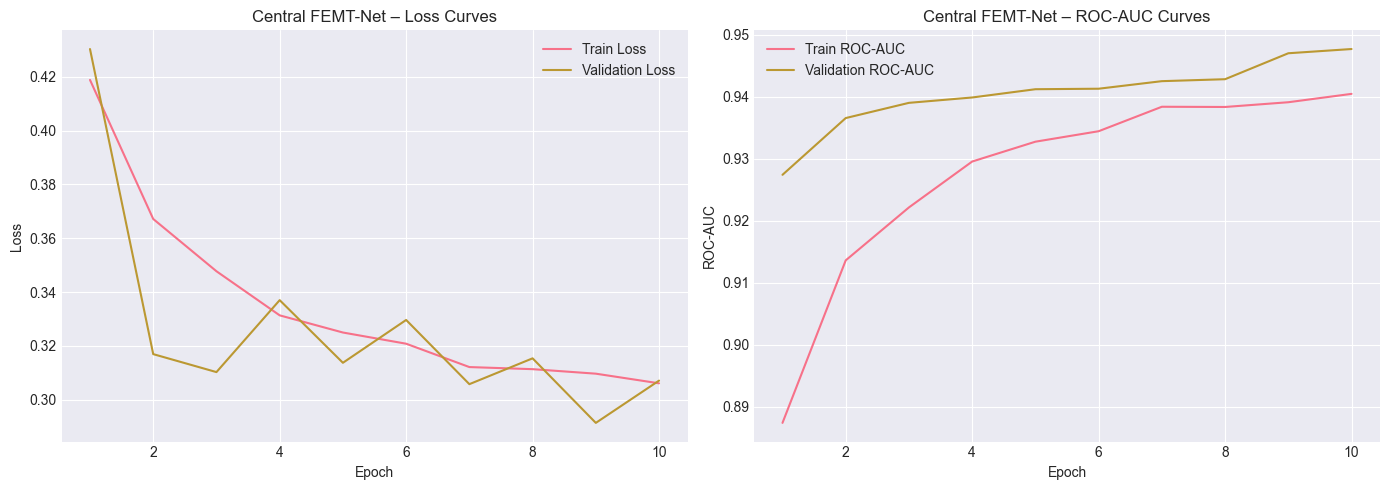

In [19]:
central_model = create_femtnet()
optimizer = torch.optim.Adam(central_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

num_epochs = 10
central_history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_state = copy.deepcopy(central_model.state_dict())
best_val_auc = -np.inf

for epoch in range(num_epochs):
    train_loss, train_metrics = run_epoch(central_model, train_loader, optimizer)
    val_loss, val_metrics = run_epoch(central_model, test_loader, optimizer=None)
    scheduler.step(val_loss)

    central_history['train_loss'].append(train_loss)
    central_history['val_loss'].append(val_loss)
    central_history['train_auc'].append(train_metrics['roc_auc'])
    central_history['val_auc'].append(val_metrics['roc_auc'])

    if np.nan_to_num(val_metrics['roc_auc'], nan=-1.0) > best_val_auc:
        best_val_auc = np.nan_to_num(val_metrics['roc_auc'], nan=-1.0)
        best_state = copy.deepcopy(central_model.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train AUC: {train_metrics['roc_auc']:.4f} | Val AUC: {val_metrics['roc_auc']:.4f}"
    )

best_central_model = create_femtnet()
best_central_model.load_state_dict(best_state)
central_true, central_prob, central_modality_weights = predict_with_model(best_central_model, test_loader)
central_results = compute_binary_metrics(central_true, central_prob)

print("\n✅ Centralized FEMT-Net evaluation")
for metric_name, metric_value in central_results.items():
    print(f"   {metric_name}: {metric_value:.4f}")

plot_training_history(central_history, title='Central FEMT-Net')

## 🔐 STEP 8: Federated Learning with Weighted FedAvg

This stage simulates a cross-silo hospital setting:
- local training happens inside each hospital/client
- only model parameters are shared
- global parameters are aggregated using weighted FedAvg based on client sample counts

In [20]:
def make_client_subsets(dataset, num_clients=3):
    shuffled_indices = np.random.permutation(len(dataset))
    split_indices = np.array_split(shuffled_indices, num_clients)
    return [Subset(dataset, idx.tolist()) for idx in split_indices if len(idx) > 0]

def weighted_fedavg(state_dicts, weights):
    total_weight = float(sum(weights))
    averaged = {}
    for key in state_dicts[0].keys():
        accumulator = None
        for state_dict, weight in zip(state_dicts, weights):
            value = state_dict[key].detach().clone().float() * (weight / total_weight)
            accumulator = value if accumulator is None else accumulator + value
        averaged[key] = accumulator.type_as(state_dicts[0][key])
    return averaged

num_clients = 3
federated_rounds = 5
local_epochs = 2
client_subsets = make_client_subsets(train_dataset, num_clients=num_clients)

federated_model = create_femtnet()
federated_history = []

for round_idx in range(federated_rounds):
    local_states = []
    local_weights = []

    for client_id, client_subset in enumerate(client_subsets, start=1):
        local_model = copy.deepcopy(federated_model)
        local_optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-3, weight_decay=1e-5)
        client_loader = DataLoader(client_subset, batch_size=batch_size, shuffle=True)

        for _ in range(local_epochs):
            run_epoch(local_model, client_loader, local_optimizer)

        local_states.append(copy.deepcopy(local_model.state_dict()))
        local_weights.append(len(client_subset))
        print(f"Round {round_idx + 1} | Client {client_id} finished local training on {len(client_subset)} samples")

    global_state = weighted_fedavg(local_states, local_weights)
    federated_model.load_state_dict(global_state)
    _, round_metrics = run_epoch(federated_model, test_loader, optimizer=None)
    federated_history.append(round_metrics)
    print(f"✅ After round {round_idx + 1}: test ROC-AUC = {round_metrics['roc_auc']:.4f}, test F1 = {round_metrics['f1']:.4f}")

federated_true, federated_prob, federated_modality_weights = predict_with_model(federated_model, test_loader)
federated_results = compute_binary_metrics(federated_true, federated_prob)

print("\n✅ Federated FEMT-Net evaluation")
for metric_name, metric_value in federated_results.items():
    print(f"   {metric_name}: {metric_value:.4f}")

Round 1 | Client 1 finished local training on 5449 samples
Round 1 | Client 2 finished local training on 5448 samples
Round 1 | Client 3 finished local training on 5448 samples
✅ After round 1: test ROC-AUC = 0.9210, test F1 = 0.7570
Round 2 | Client 1 finished local training on 5449 samples
Round 2 | Client 2 finished local training on 5448 samples
Round 2 | Client 3 finished local training on 5448 samples
✅ After round 2: test ROC-AUC = 0.9340, test F1 = 0.8500
Round 3 | Client 1 finished local training on 5449 samples
Round 3 | Client 2 finished local training on 5448 samples
Round 3 | Client 3 finished local training on 5448 samples
✅ After round 3: test ROC-AUC = 0.9374, test F1 = 0.8237
Round 4 | Client 1 finished local training on 5449 samples
Round 4 | Client 2 finished local training on 5448 samples
Round 4 | Client 3 finished local training on 5448 samples
✅ After round 4: test ROC-AUC = 0.9399, test F1 = 0.8632
Round 5 | Client 1 finished local training on 5449 samples
Round

## 🔍 STEP 9: Explainability, Evaluation, Saving, and Inference

This final section covers:
- quantitative comparison of centralized and federated FEMT-Net
- confusion matrices and ROC curves
- modality contribution visualization
- ECG saliency via a Grad-CAM-style 1D method
- SHAP over a clinical-feature surrogate model
- saving reusable artifacts and defining an inference function

                   accuracy precision  recall      f1 roc_auc
Model                                                        
Central FEMT-Net     0.8701    0.9210  0.8278  0.8720  0.9477
Federated FEMT-Net   0.8644    0.8896  0.8521  0.8704  0.9404


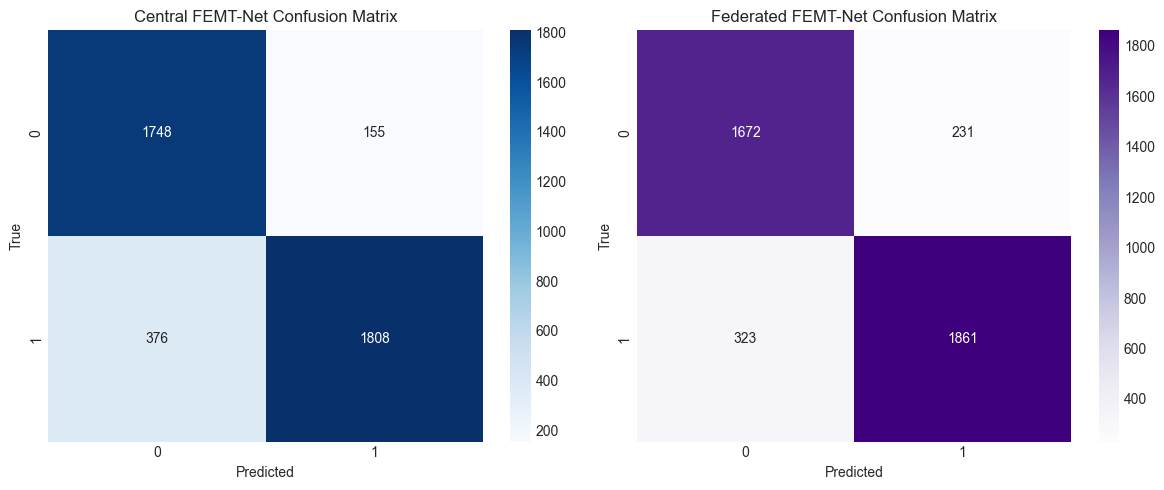

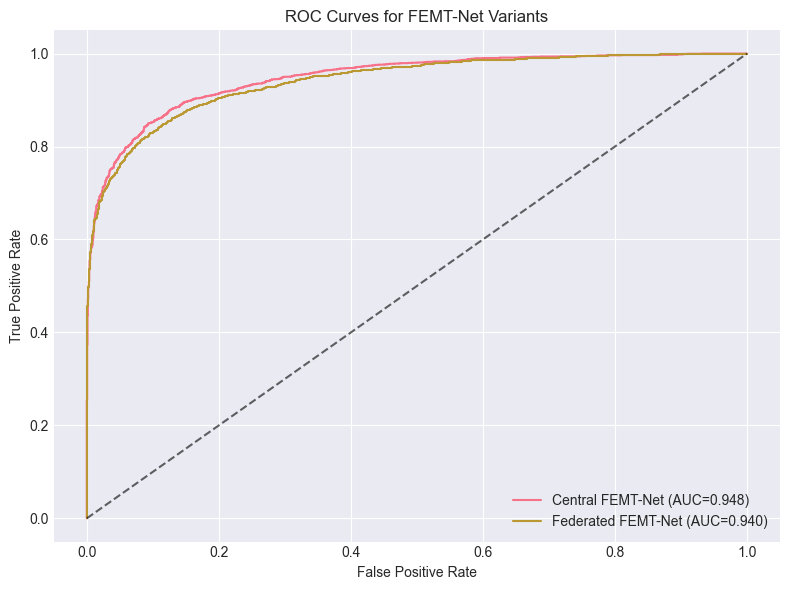

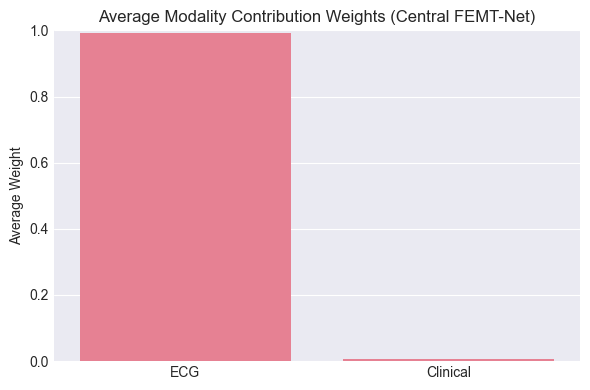

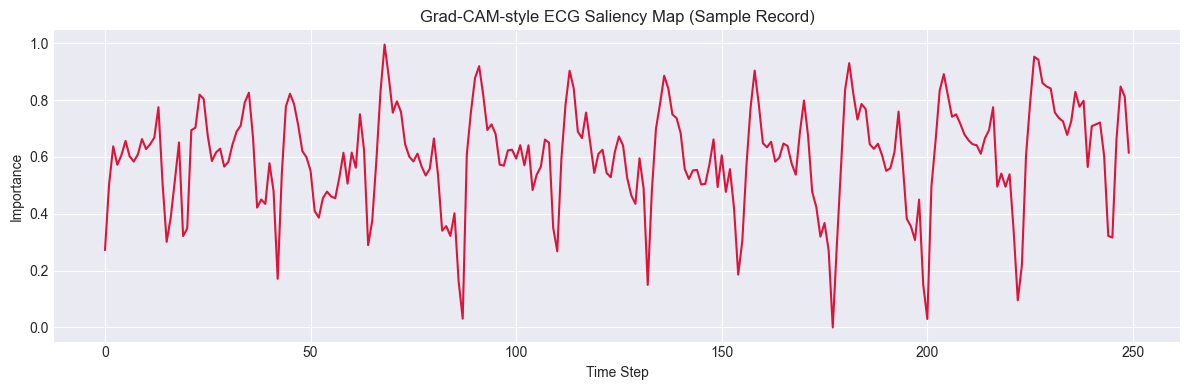

<Figure size 1000x600 with 0 Axes>

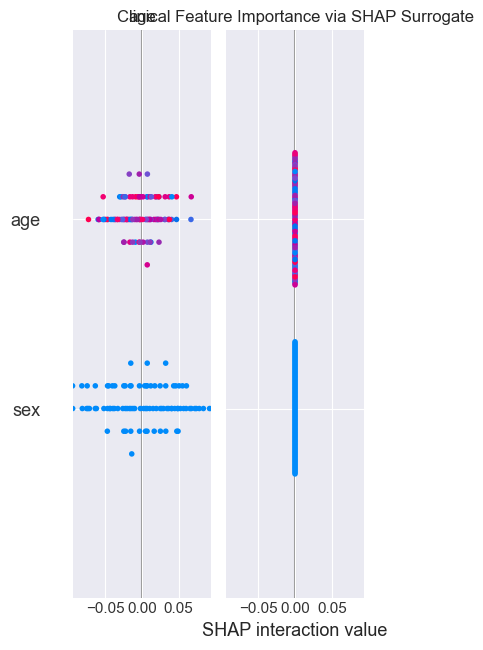


🔮 Example multimodal prediction
{'prediction': 1, 'probability': 0.9806821346282959, 'ecg_weight': 0.9876070618629456, 'clinical_weight': 0.01239290926605463}

✅ FEMT-Net notebook rewrite complete and aligned with the document architecture.


In [21]:
comparison_df = pd.DataFrame([
    {'Model': 'Central FEMT-Net', **central_results},
    {'Model': 'Federated FEMT-Net', **federated_results},
]).set_index('Model')
print(comparison_df.applymap(lambda value: f"{value:.4f}" if isinstance(value, float) else value))

central_pred = (central_prob >= 0.5).astype(int)
federated_pred = (federated_prob >= 0.5).astype(int)

_, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(central_true, central_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Central FEMT-Net Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(confusion_matrix(federated_true, federated_pred), annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title('Federated FEMT-Net Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, y_true, y_prob in [('Central FEMT-Net', central_true, central_prob), ('Federated FEMT-Net', federated_true, federated_prob)]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('ROC Curves for FEMT-Net Variants')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

avg_modality_weights = central_modality_weights.mean(axis=0)
plt.figure(figsize=(6, 4))
sns.barplot(x=['ECG', 'Clinical'], y=avg_modality_weights)
plt.title('Average Modality Contribution Weights (Central FEMT-Net)')
plt.ylabel('Average Weight')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activations)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, _module, _inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, _module, _grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, ecg_tensor, clinical_tensor):
        self.model.eval()
        self.model.zero_grad()
        logits, _, _ = self.model(ecg_tensor, clinical_tensor)
        logits.backward(torch.ones_like(logits))
        weights = self.gradients.mean(dim=2, keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1)).squeeze(0)
        cam = cam.cpu().numpy()
        cam = cam / (cam.max() + 1e-6)
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

sample_index = 0
sample_ecg_tensor = torch.tensor(test_ecg[sample_index:sample_index + 1], dtype=torch.float32, device=device)
sample_clinical_tensor = torch.tensor(test_clinical_scaled[sample_index:sample_index + 1], dtype=torch.float32, device=device)
gradcam = GradCAM1D(best_central_model, best_central_model.ecg_encoder.conv3)
ecg_saliency = gradcam.generate(sample_ecg_tensor, sample_clinical_tensor)
gradcam.close()

plt.figure(figsize=(12, 4))
plt.plot(ecg_saliency, color='crimson')
plt.title('Grad-CAM-style ECG Saliency Map (Sample Record)')
plt.xlabel('Time Step')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

surrogate_model = RandomForestClassifier(n_estimators=200, random_state=42)
surrogate_model.fit(train_clinical_scaled, train_labels.astype(int))
try:
    clinical_explainer = shap.TreeExplainer(surrogate_model)
    shap_values = clinical_explainer.shap_values(test_clinical_scaled[:100])
    shap_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_to_plot, test_clinical_scaled[:100], feature_names=clinical_feature_names, plot_type='bar', show=False)
    plt.title('Clinical Feature Importance via SHAP Surrogate')
    plt.tight_layout()
    plt.show()
except Exception as shap_error:
    print(f"⚠️ SHAP visualization skipped: {shap_error}")

os.makedirs('models', exist_ok=True)
torch.save({
    'state_dict': best_central_model.state_dict(),
    'num_leads': num_leads,
    'clinical_dim': train_clinical_scaled.shape[1],
    'signal_length': signal_length,
    'clinical_feature_names': clinical_feature_names,
    'results': central_results
}, 'models/femtnet_central.pth')

torch.save({
    'state_dict': federated_model.state_dict(),
    'num_leads': num_leads,
    'clinical_dim': train_clinical_scaled.shape[1],
    'signal_length': signal_length,
    'clinical_feature_names': clinical_feature_names,
    'results': federated_results
}, 'models/femtnet_federated.pth')

with open('models/clinical_imputer.pkl', 'wb') as file_obj:
    pickle.dump(clinical_imputer, file_obj)
with open('models/clinical_scaler.pkl', 'wb') as file_obj:
    pickle.dump(clinical_scaler, file_obj)
with open('models/clinical_feature_names.pkl', 'wb') as file_obj:
    pickle.dump(clinical_feature_names, file_obj)

def prepare_ecg_signal(ecg_signal, expected_leads=num_leads, expected_length=signal_length):
    ecg_signal = np.asarray(ecg_signal, dtype=np.float32)
    if ecg_signal.ndim != 2:
        raise ValueError('ECG signal must be a 2D array with shape [leads, time] or [time, leads].')
    if ecg_signal.shape[0] != expected_leads and ecg_signal.shape[1] == expected_leads:
        ecg_signal = ecg_signal.T
    if ecg_signal.shape[0] != expected_leads:
        raise ValueError(f'Expected {expected_leads} ECG leads but received shape {ecg_signal.shape}.')
    if ecg_signal.shape[1] >= expected_length:
        ecg_signal = ecg_signal[:, :expected_length]
    else:
        pad_width = expected_length - ecg_signal.shape[1]
        ecg_signal = np.pad(ecg_signal, ((0, 0), (0, pad_width)), mode='constant')
    return ecg_signal.astype(np.float32)

def prepare_clinical_vector(clinical_input):
    if isinstance(clinical_input, dict):
        vector = np.array([[clinical_input.get(feature_name, np.nan) for feature_name in clinical_feature_names]], dtype=np.float32)
    else:
        vector = np.asarray(clinical_input, dtype=np.float32).reshape(1, -1)
    vector = clinical_imputer.transform(vector)
    vector = clinical_scaler.transform(vector)
    return vector.astype(np.float32)

def predict_cardiovascular_risk(ecg_signal, clinical_input, use_federated=False):
    model = federated_model if use_federated else best_central_model
    model.eval()
    prepared_ecg = prepare_ecg_signal(ecg_signal)
    prepared_clinical = prepare_clinical_vector(clinical_input)

    ecg_tensor = torch.tensor(prepared_ecg[None, ...], dtype=torch.float32, device=device)
    clinical_tensor = torch.tensor(prepared_clinical, dtype=torch.float32, device=device)

    with torch.no_grad():
        logits, modality_weights, _ = model(ecg_tensor, clinical_tensor)
        probability = torch.softmax(logits, dim=1)[:, 1].item()

    prediction = int(probability >= 0.5)
    contribution = modality_weights.cpu().numpy()[0]
    return {
        'prediction': prediction,
        'probability': probability,
        'ecg_weight': float(contribution[0]),
        'clinical_weight': float(contribution[1])
    }

example_result = predict_cardiovascular_risk(test_ecg[0], test_clinical_raw.iloc[0].to_dict(), use_federated=False)
print("\n🔮 Example multimodal prediction")
print(example_result)
print("\n✅ FEMT-Net notebook rewrite complete and aligned with the document architecture.")


## 📊 STEP 10: Baseline Model Comparisons & Extended Visualizations

Compare **FEMT-Net** against classical ML baselines (clinical features only) and unimodal deep-learning ablations (ECG-only CNN, Clinical-only MLP).

| Model | Type | What it isolates |
|---|---|---|
| Logistic Regression | Classical ML | Linear boundary, clinical only |
| Random Forest | Classical ML | Non-linear tabular, clinical only |
| SVM (RBF) | Classical ML | Kernel boundary, clinical only |
| ECG-only CNN | Deep ablation | Value of ECG without clinical context |
| Clinical-only MLP | Deep ablation | Value of clinical without ECG |
| Central FEMT-Net | **Proposed** | Full multimodal fusion |
| Federated FEMT-Net | **Proposed** | Privacy-preserving federated variant |


✅ Logistic Regression: AUC=0.5144  F1=0.6965  Acc=0.5344
✅ Random Forest: AUC=0.4939  F1=0.5691  Acc=0.5009
✅ SVM (RBF): AUC=0.5004  F1=0.6965  Acc=0.5344
✅ ECG-only CNN:      AUC=0.9471  F1=0.8616  Acc=0.8622
✅ Clinical-only MLP: AUC=0.5079  F1=0.6965  Acc=0.5344

📊 Full Model Comparison
                    accuracy precision  recall      f1 roc_auc
Logistic Regression   0.5344    0.5344  1.0000  0.6965  0.5144
Random Forest         0.5009    0.5282  0.6168  0.5691  0.4939
SVM (RBF)             0.5344    0.5344  1.0000  0.6965  0.5004
ECG-only CNN          0.8622    0.9300  0.8027  0.8616  0.9471
Clinical-only MLP     0.5344    0.5344  1.0000  0.6965  0.5079
Central FEMT-Net      0.8701    0.9210  0.8278  0.8720  0.9477
Federated FEMT-Net    0.8644    0.8896  0.8521  0.8704  0.9404


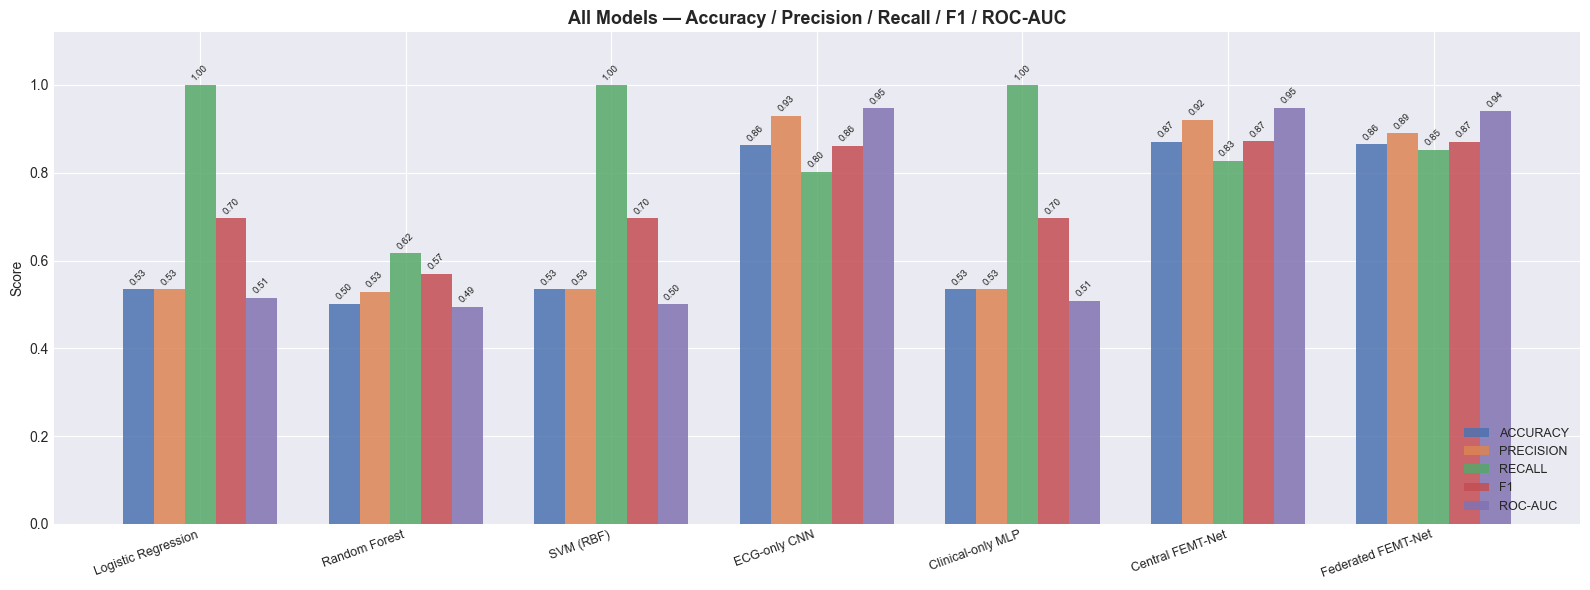

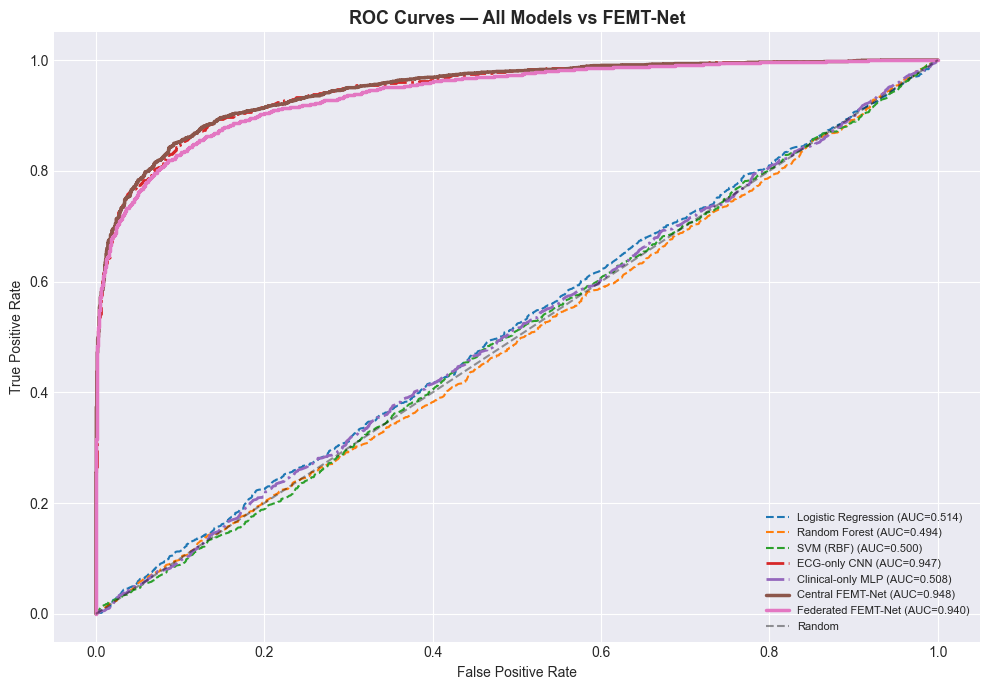

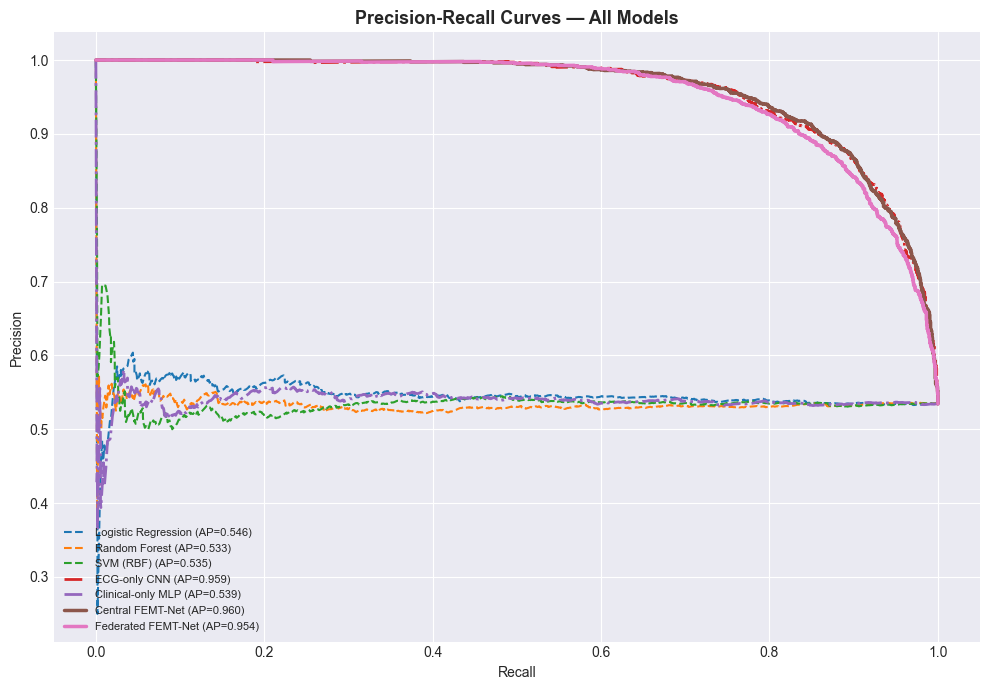

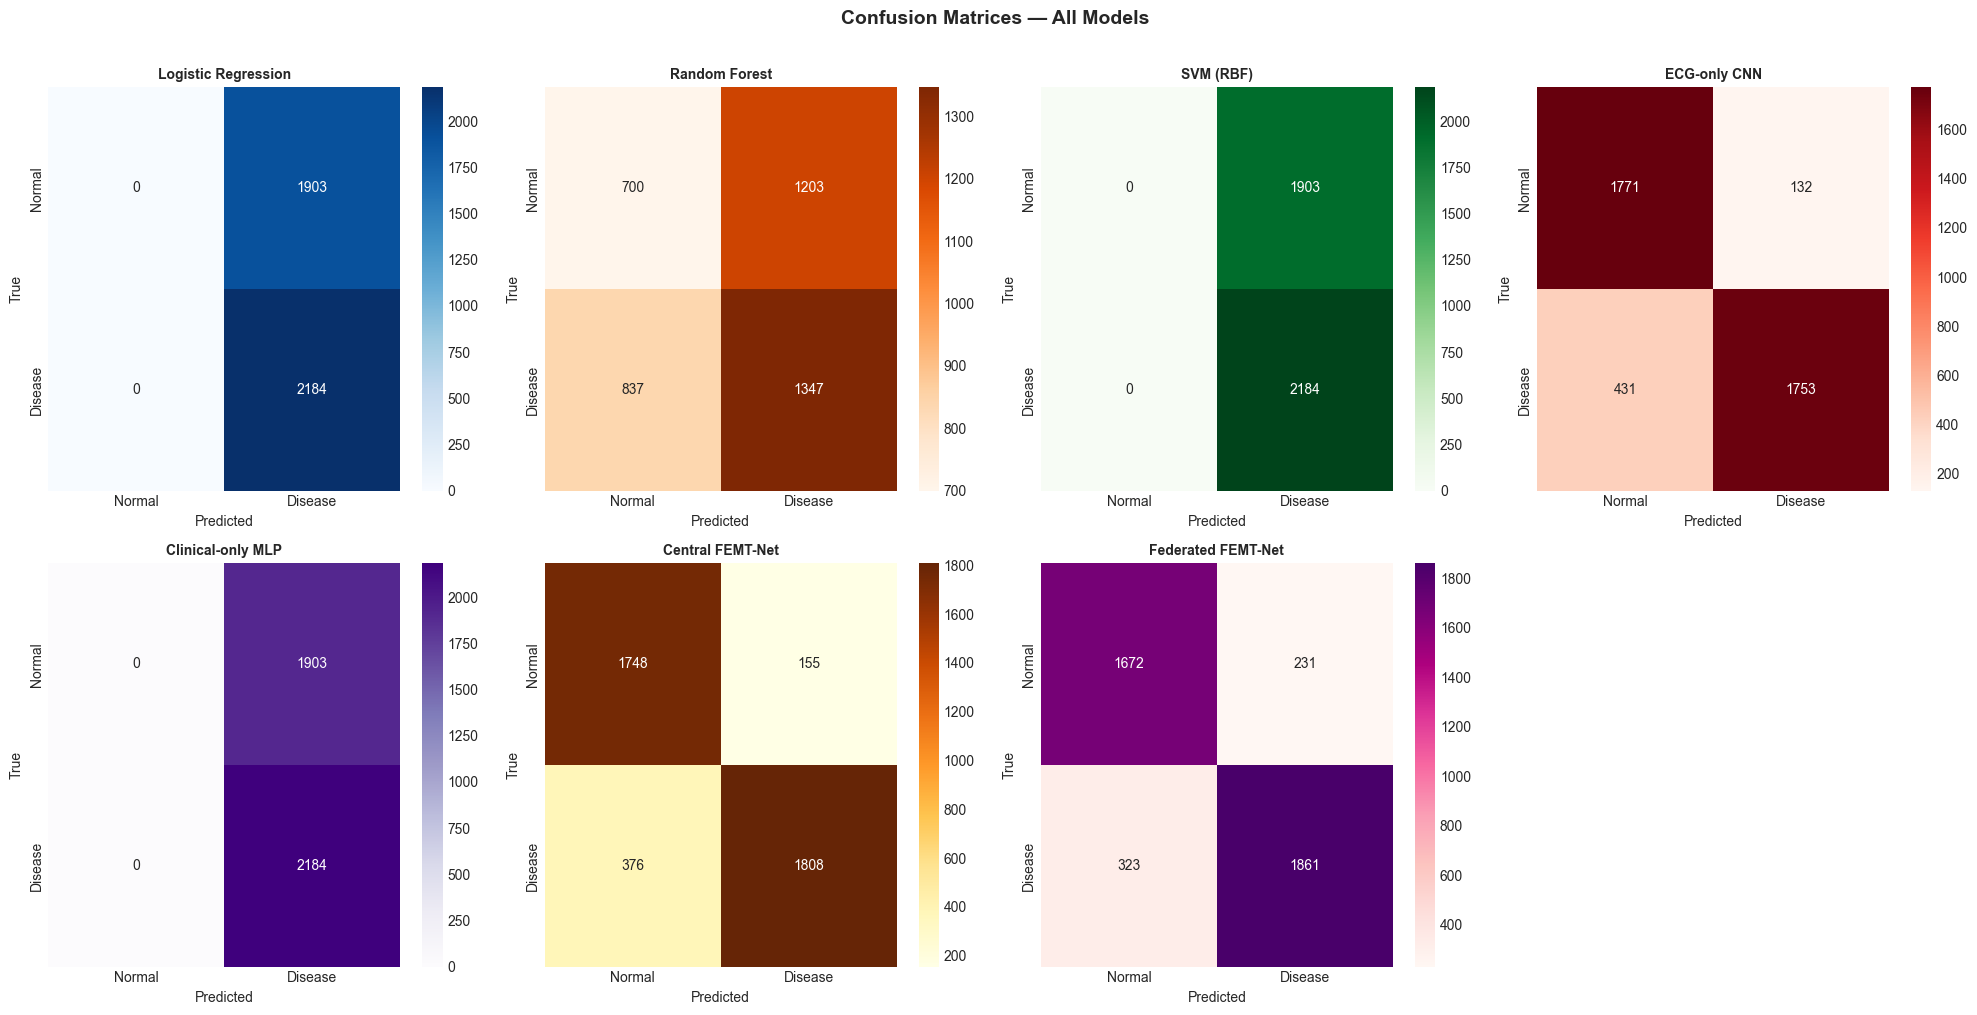

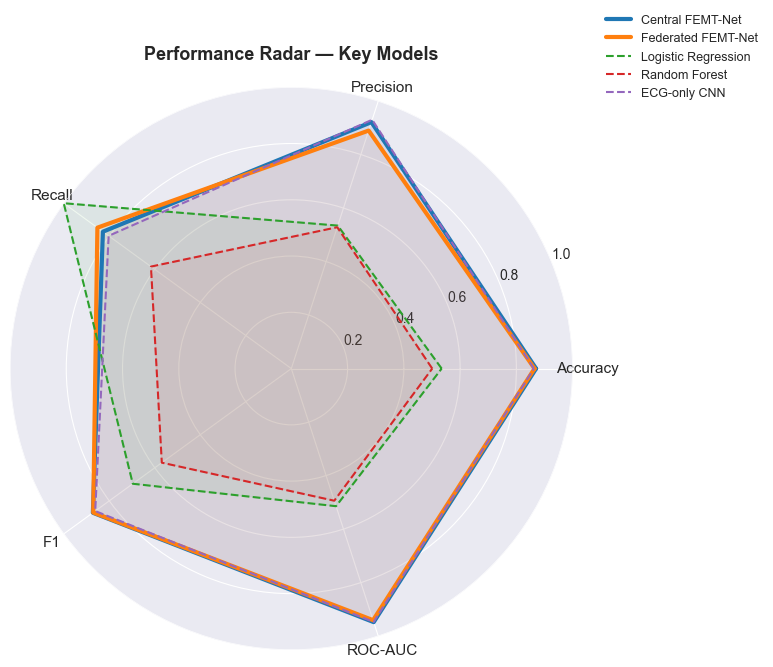

  FEMT-Net vs Best Baseline

  Central FEMT-Net
    ROC-AUC : 0.9477  (Δ +0.0006 vs best baseline)
    F1 Score: 0.8720  (Δ +0.0103 vs best baseline)

  Federated FEMT-Net
    ROC-AUC : 0.9404  (Δ -0.0067 vs best baseline)
    F1 Score: 0.8704  (Δ +0.0088 vs best baseline)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── 1. Classical ML baselines (clinical features only) ────────────────────
baselines_ml = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
}

baseline_results = {}
baseline_probs = {}
for name, clf in baselines_ml.items():
    clf.fit(train_clinical_scaled, train_labels.astype(int))
    prob = clf.predict_proba(test_clinical_scaled)[:, 1]
    baseline_results[name] = compute_binary_metrics(test_labels, prob)
    baseline_probs[name] = prob
    print(f"✅ {name}: AUC={baseline_results[name]['roc_auc']:.4f}  F1={baseline_results[name]['f1']:.4f}  Acc={baseline_results[name]['accuracy']:.4f}")

# ── 2. ECG-only CNN ablation ──────────────────────────────────────────────
class ECGOnlyModel(nn.Module):
    def __init__(self, num_leads):
        super().__init__()
        self.ecg_encoder = ECGCNNEncoder(num_leads)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 2)
        )
    def forward(self, ecg, clinical):
        return self.classifier(self.ecg_encoder(ecg)), None, None

ecg_only_model = ECGOnlyModel(num_leads=num_leads).to(device)
ecg_only_optimizer = torch.optim.Adam(ecg_only_model.parameters(), lr=1e-3)
for _ in range(10):
    run_epoch(ecg_only_model, train_loader, ecg_only_optimizer)
ecg_only_true, ecg_only_prob, _ = predict_with_model(ecg_only_model, test_loader)
baseline_results['ECG-only CNN'] = compute_binary_metrics(ecg_only_true, ecg_only_prob)
baseline_probs['ECG-only CNN'] = ecg_only_prob
print(f"✅ ECG-only CNN:      AUC={baseline_results['ECG-only CNN']['roc_auc']:.4f}  F1={baseline_results['ECG-only CNN']['f1']:.4f}  Acc={baseline_results['ECG-only CNN']['accuracy']:.4f}")

# ── 3. Clinical-only MLP ablation ─────────────────────────────────────────
class ClinicalOnlyModel(nn.Module):
    def __init__(self, clinical_dim):
        super().__init__()
        self.clinical_encoder = ClinicalEncoder(clinical_dim)
        self.classifier = nn.Sequential(
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.3), nn.Linear(16, 2)
        )
    def forward(self, ecg, clinical):
        return self.classifier(self.clinical_encoder(clinical)), None, None

clinical_only_model = ClinicalOnlyModel(clinical_dim=train_clinical_scaled.shape[1]).to(device)
clinical_only_optimizer = torch.optim.Adam(clinical_only_model.parameters(), lr=1e-3)
for _ in range(10):
    run_epoch(clinical_only_model, train_loader, clinical_only_optimizer)
clin_only_true, clin_only_prob, _ = predict_with_model(clinical_only_model, test_loader)
baseline_results['Clinical-only MLP'] = compute_binary_metrics(clin_only_true, clin_only_prob)
baseline_probs['Clinical-only MLP'] = clin_only_prob
print(f"✅ Clinical-only MLP: AUC={baseline_results['Clinical-only MLP']['roc_auc']:.4f}  F1={baseline_results['Clinical-only MLP']['f1']:.4f}  Acc={baseline_results['Clinical-only MLP']['accuracy']:.4f}")

# ── 4. Full comparison table ──────────────────────────────────────────────
all_results = {
    **baseline_results,
    'Central FEMT-Net':   central_results,
    'Federated FEMT-Net': federated_results,
}
all_probs = {
    **baseline_probs,
    'Central FEMT-Net':   central_prob,
    'Federated FEMT-Net': federated_prob,
}
comparison_full = pd.DataFrame(all_results).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
comparison_full_display = comparison_full.applymap(lambda v: f"{v:.4f}" if isinstance(v, float) else v)
print("\n📊 Full Model Comparison")
print(comparison_full_display.to_string())

# ── 5. Grouped bar chart: all metrics ─────────────────────────────────────
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
model_names = list(all_results.keys())
x = np.arange(len(model_names))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics_to_plot):
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric.upper().replace('_', '-'), color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title('All Models — Accuracy / Precision / Recall / F1 / ROC-AUC', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

# ── 6. ROC curves: all models ─────────────────────────────────────────────
line_styles = ['--', '--', '--', '-.', '-.', '-', '-']
line_widths = [1.5, 1.5, 1.5, 2.0, 2.0, 2.5, 2.5]
palette = plt.cm.tab10.colors

plt.figure(figsize=(10, 7))
for i, (name, prob) in enumerate(all_probs.items()):
    y_true = test_labels if name in baseline_probs else (
        central_true if name == 'Central FEMT-Net' else federated_true
    )
    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle=line_styles[i], linewidth=line_widths[i],
             color=palette[i], label=f'{name} (AUC={roc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.title('ROC Curves — All Models vs FEMT-Net', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

# ── 7. Precision-Recall curves ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))
for i, (name, prob) in enumerate(all_probs.items()):
    y_true = test_labels if name in baseline_probs else (
        central_true if name == 'Central FEMT-Net' else federated_true
    )
    prec, rec, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)
    plt.plot(rec, prec, linestyle=line_styles[i], linewidth=line_widths[i],
             color=palette[i], label=f'{name} (AP={ap:.3f})')

plt.title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 8. Confusion matrices: all 7 models ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
cmap_list = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 'YlOrBr', 'RdPu']

for i, (name, prob) in enumerate(all_probs.items()):
    y_true = test_labels if name in baseline_probs else (
        central_true if name == 'Central FEMT-Net' else federated_true
    )
    y_pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_list[i], ax=axes[i],
                xticklabels=['Normal', 'Disease'], yticklabels=['Normal', 'Disease'])
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── 9. Radar / spider chart ───────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

radar_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
radar_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
num_vars = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
highlight_models = ['Central FEMT-Net', 'Federated FEMT-Net', 'Logistic Regression', 'Random Forest', 'ECG-only CNN']

for i, name in enumerate(highlight_models):
    vals = [all_results[name][m] for m in radar_metrics]
    vals += vals[:1]
    lw = 3 if 'FEMT' in name else 1.5
    ls = '-' if 'FEMT' in name else '--'
    ax.plot(angles, vals, linewidth=lw, linestyle=ls, color=palette[i], label=name)
    ax.fill(angles, vals, alpha=0.07, color=palette[i])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Performance Radar — Key Models', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

# ── 10. Improvement over best baseline ────────────────────────────────────
best_baseline_auc = max(baseline_results[m]['roc_auc'] for m in baseline_results)
best_baseline_f1  = max(baseline_results[m]['f1']      for m in baseline_results)

print("=" * 55)
print("  FEMT-Net vs Best Baseline")
print("=" * 55)
for variant, res in [('Central FEMT-Net', central_results), ('Federated FEMT-Net', federated_results)]:
    delta_auc = res['roc_auc'] - best_baseline_auc
    delta_f1  = res['f1']      - best_baseline_f1
    print(f"\n  {variant}")
    print(f"    ROC-AUC : {res['roc_auc']:.4f}  (Δ {delta_auc:+.4f} vs best baseline)")
    print(f"    F1 Score: {res['f1']:.4f}  (Δ {delta_f1:+.4f} vs best baseline)")
print("=" * 55)
